# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Walt Disney World Dataset](https://www.kaggle.com/datasets/chadwambles/walt-disney-world-wait-times?select=calendar_enriched.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/ll_classification.csv
/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/chained_index.csv
/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/coverage_by_year.csv
/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/calendar_enriched.csv
/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/ll_split_index.csv
/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/park_stats.csv
/kaggle/input/datasets/chadwambles/walt-disney-world-wait-times/ride_stats.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('calendar_enriched.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,park_id,park_name,date,year,month,month_name,day_of_week,dow_number,is_weekend,crowd_level_pct,crowd_rel_to_year,operating_minutes,has_early_entry,has_extended_evening,has_special_event,is_holiday,is_rainy
0,5,Epcot,2015-01-01,2015,1,Jan,Thursday,4,0,73,1.344,780.0,0,0,0,1,0
1,5,Epcot,2015-01-02,2015,1,Jan,Friday,5,0,74,1.363,780.0,0,0,0,0,0
2,5,Epcot,2015-01-03,2015,1,Jan,Saturday,6,1,58,1.068,720.0,0,0,0,0,0
3,5,Epcot,2015-01-04,2015,1,Jan,Sunday,7,1,14,0.258,720.0,0,0,0,0,0
4,5,Epcot,2015-01-05,2015,1,Jan,Monday,1,0,15,0.276,720.0,0,0,0,0,0


## last Five row

In [4]:
df.tail()

,park_id,park_name,date,year,month,month_name,day_of_week,dow_number,is_weekend,crowd_level_pct,crowd_rel_to_year,operating_minutes,has_early_entry,has_extended_evening,has_special_event,is_holiday,is_rainy
16677,8,Animal Kingdom,2026-09-26,2026,9,Sep,Saturday,6,1,19,0.492,720.0,1,0,0,0,0
16678,8,Animal Kingdom,2026-09-27,2026,9,Sep,Sunday,7,1,17,0.440,600.0,1,0,0,0,0
16679,8,Animal Kingdom,2026-09-28,2026,9,Sep,Monday,1,0,20,0.518,600.0,1,0,0,0,0
16680,8,Animal Kingdom,2026-09-29,2026,9,Sep,Tuesday,2,0,16,0.414,600.0,1,0,0,0,0
16681,8,Animal Kingdom,2026-09-30,2026,9,Sep,Wednesday,3,0,13,0.336,600.0,1,0,0,0,0


## Shape of our dataset

In [5]:
df.shape

(16682, 17)

## List out all columns

In [6]:
df.columns

Index(['park_id', 'park_name', 'date', 'year', 'month', 'month_name',
       'day_of_week', 'dow_number', 'is_weekend', 'crowd_level_pct',
       'crowd_rel_to_year', 'operating_minutes', 'has_early_entry',
       'has_extended_evening', 'has_special_event', 'is_holiday', 'is_rainy'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

park_id                   int64
park_name                object
date                     object
year                      int64
month                     int64
month_name               object
day_of_week              object
dow_number                int64
is_weekend                int64
crowd_level_pct           int64
crowd_rel_to_year       float64
operating_minutes       float64
has_early_entry           int64
has_extended_evening      int64
has_special_event         int64
is_holiday                int64
is_rainy                  int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16682 entries, 0 to 16681
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   park_id               16682 non-null  int64  
 1   park_name             16682 non-null  object 
 2   date                  16682 non-null  object 
 3   year                  16682 non-null  int64  
 4   month                 16682 non-null  int64  
 5   month_name            16682 non-null  object 
 6   day_of_week           16682 non-null  object 
 7   dow_number            16682 non-null  int64  
 8   is_weekend            16682 non-null  int64  
 9   crowd_level_pct       16682 non-null  int64  
 10  crowd_rel_to_year     16682 non-null  float64
 11  operating_minutes     16052 non-null  float64
 12  has_early_entry       16682 non-null  int64  
 13  has_extended_evening  16682 non-null  int64  
 14  has_special_event     16682 non-null  int64  
 15  is_holiday         

## Check Null Value

In [9]:
df.isnull().sum()

park_id                   0
park_name                 0
date                      0
year                      0
month                     0
month_name                0
day_of_week               0
dow_number                0
is_weekend                0
crowd_level_pct           0
crowd_rel_to_year         0
operating_minutes       630
has_early_entry           0
has_extended_evening      0
has_special_event         0
is_holiday                0
is_rainy                  0
dtype: int64

## Drop Null Feathers

In [10]:
df.drop('operating_minutes', axis=1, inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,park_id,year,month,dow_number,is_weekend,crowd_level_pct,crowd_rel_to_year,has_early_entry,has_extended_evening,has_special_event,is_holiday,is_rainy
count,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000,16682.000000
mean,6.500420,2020.391560,6.468409,4.001259,0.286057,52.765076,0.999994,0.415178,0.029793,0.034468,0.032130,0.217120
std,1.118014,3.440122,3.453024,2.000404,0.451930,27.736045,0.512644,0.492767,0.170020,0.182434,0.176352,0.412298
min,5.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,2017.000000,3.000000,2.000000,0.000000,30.000000,0.618000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,2021.000000,7.000000,4.000000,0.000000,54.000000,1.015000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,2023.000000,9.000000,6.000000,1.000000,77.000000,1.348000,1.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,2026.000000,12.000000,7.000000,1.000000,100.000000,3.148000,1.000000,1.000000,1.000000,1.000000,1.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

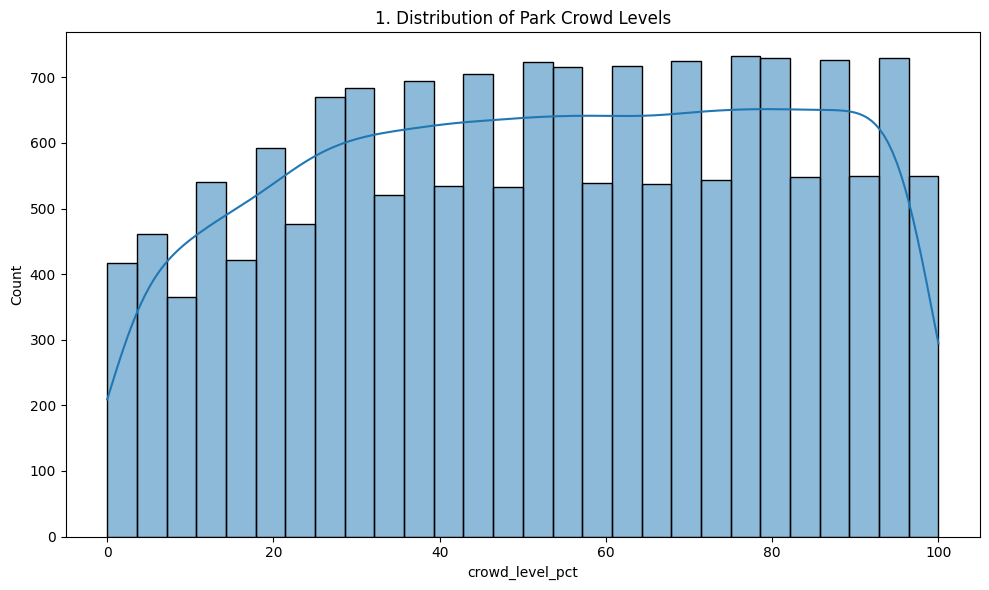

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='crowd_level_pct', kde=True)
plt.title(f'{plot_no}. Distribution of Park Crowd Levels')
show_fig()
plot_no += 1

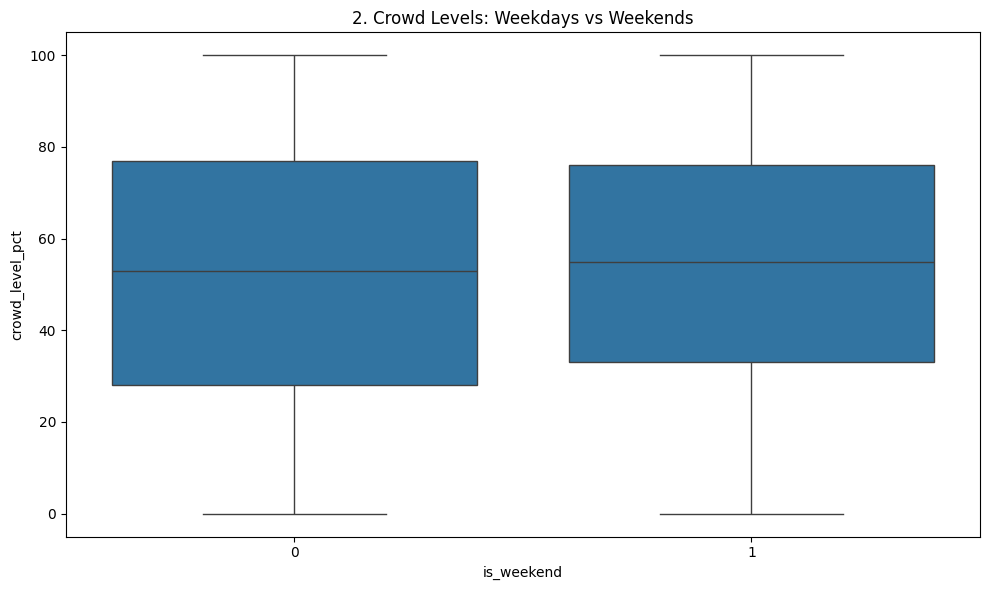

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='is_weekend', y='crowd_level_pct')
plt.title(f'{plot_no}. Crowd Levels: Weekdays vs Weekends')
show_fig()
plot_no += 1

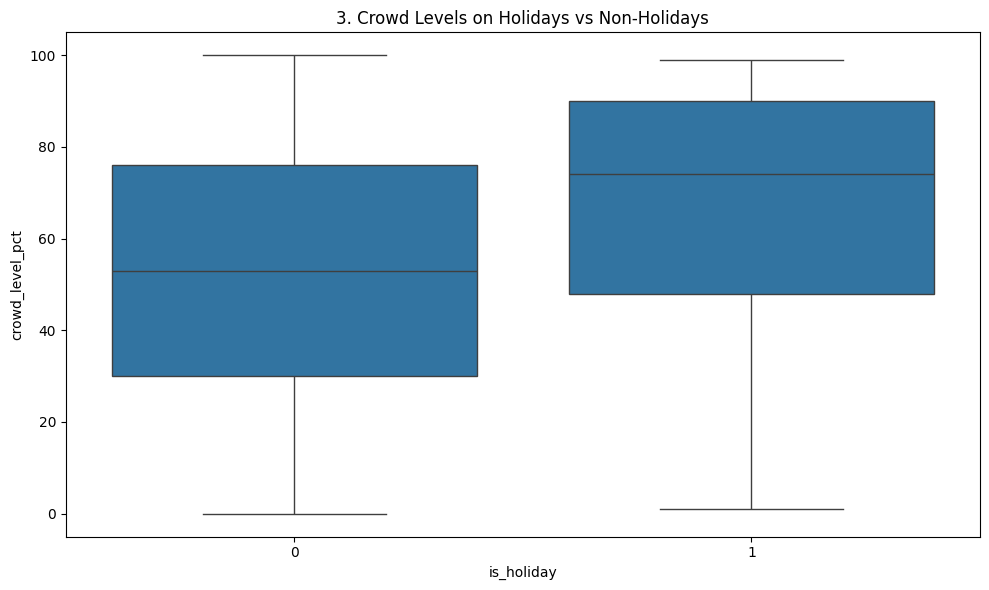

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='is_holiday', y='crowd_level_pct')
plt.title(f'{plot_no}. Crowd Levels on Holidays vs Non-Holidays')
show_fig()
plot_no += 1

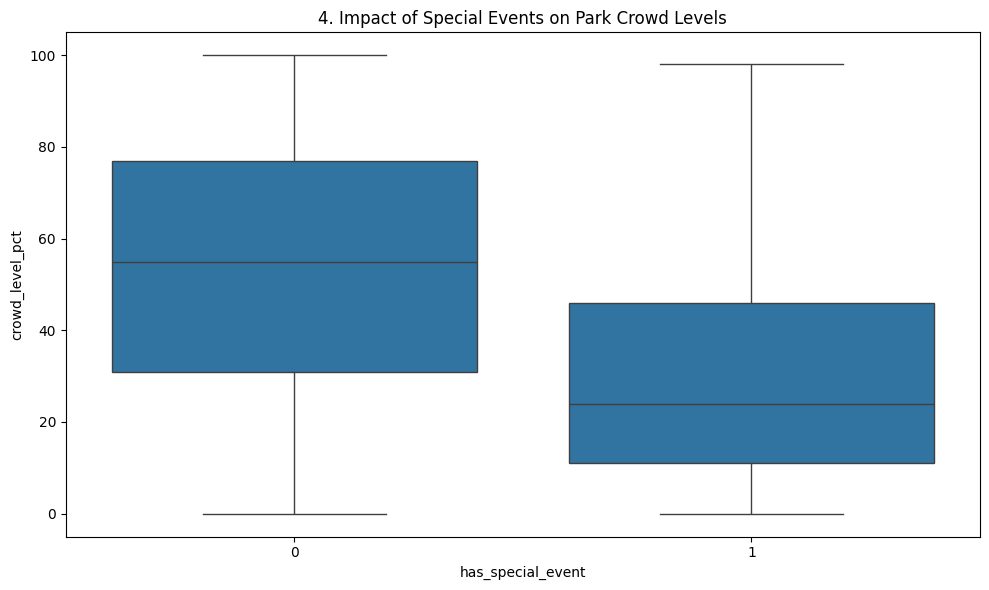

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='has_special_event', y='crowd_level_pct')
plt.title(f'{plot_no}. Impact of Special Events on Park Crowd Levels')
show_fig()
plot_no += 1

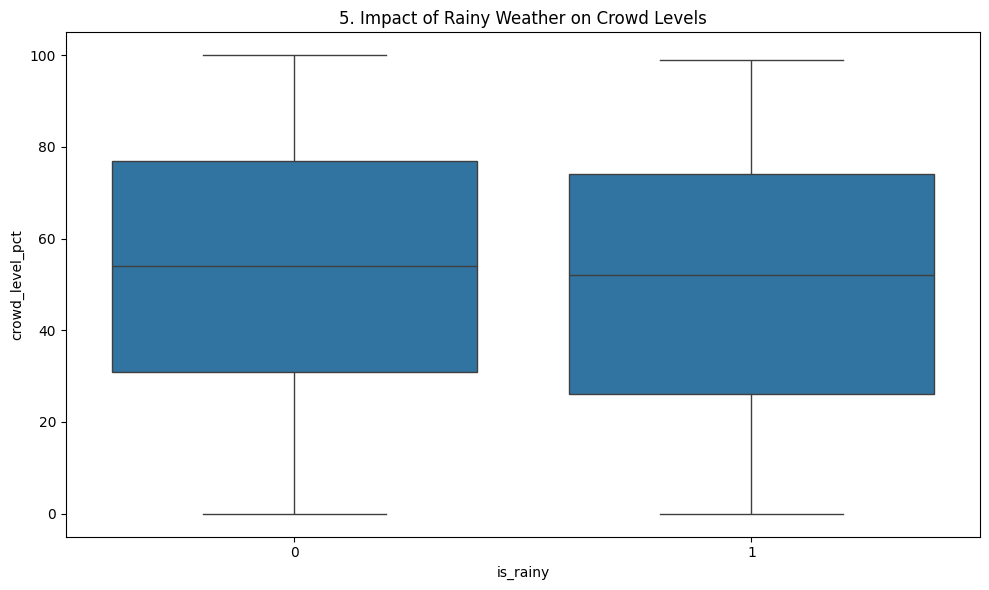

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='is_rainy', y='crowd_level_pct')
plt.title(f'{plot_no}. Impact of Rainy Weather on Crowd Levels')
show_fig()
plot_no += 1

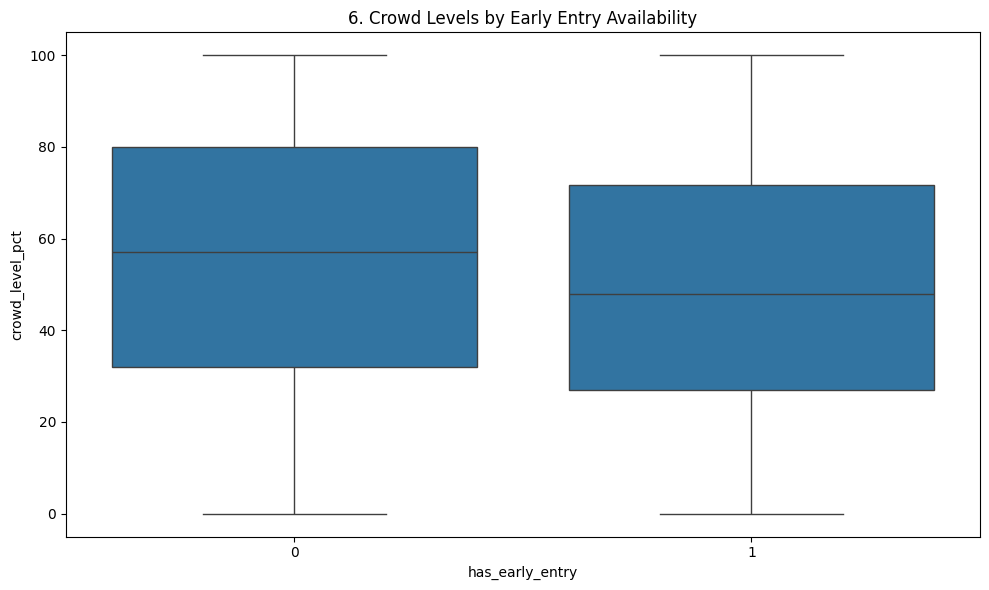

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='has_early_entry', y='crowd_level_pct')
plt.title(f'{plot_no}. Crowd Levels by Early Entry Availability')
show_fig()
plot_no += 1

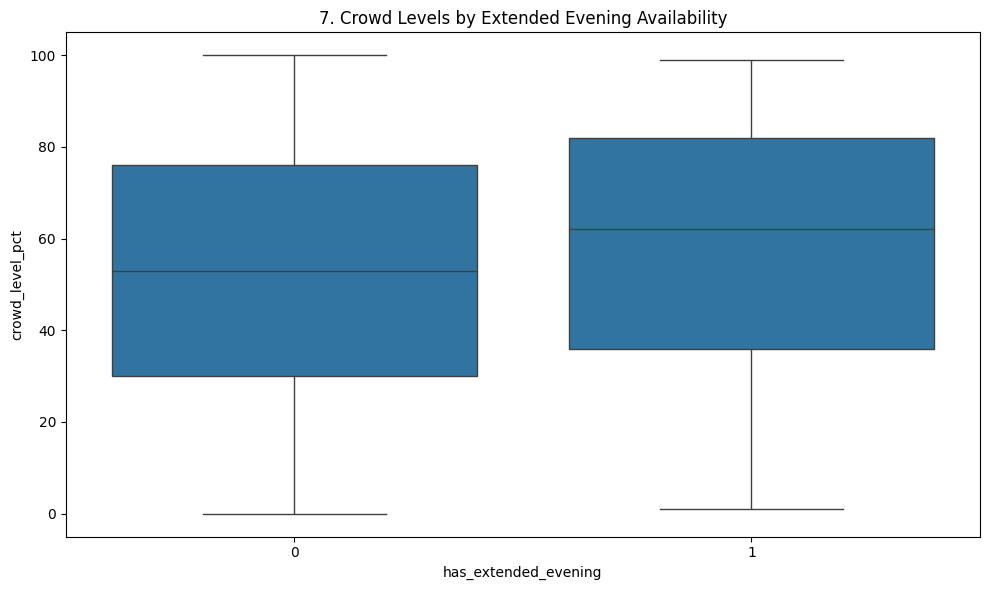

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='has_extended_evening', y='crowd_level_pct')
plt.title(f'{plot_no}. Crowd Levels by Extended Evening Availability')
show_fig()
plot_no += 1

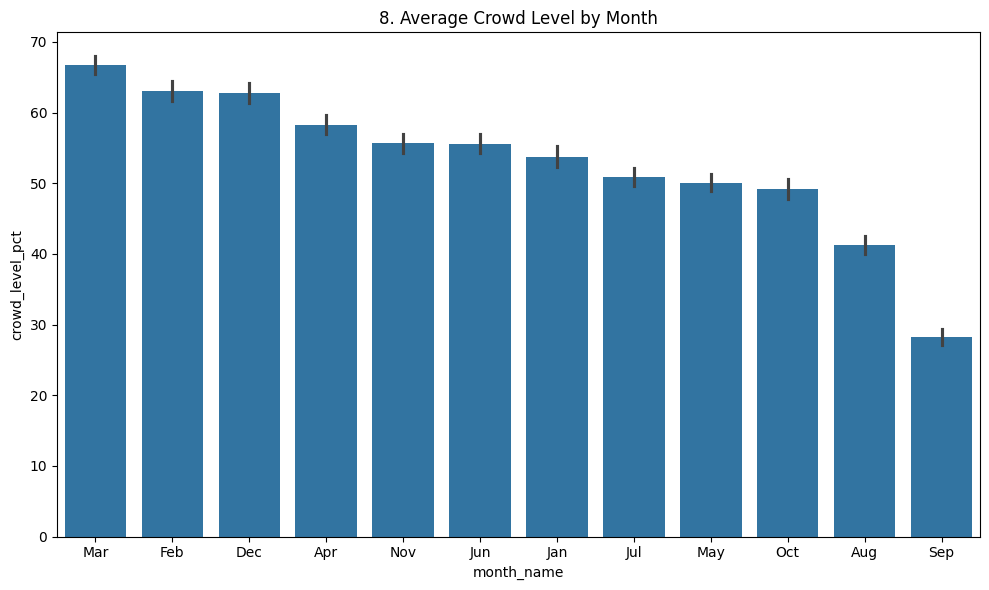

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='month_name', y='crowd_level_pct', order=df.groupby('month_name')['crowd_level_pct'].mean().sort_values(ascending=False).index)
plt.title(f'{plot_no}. Average Crowd Level by Month')
show_fig()
plot_no += 1

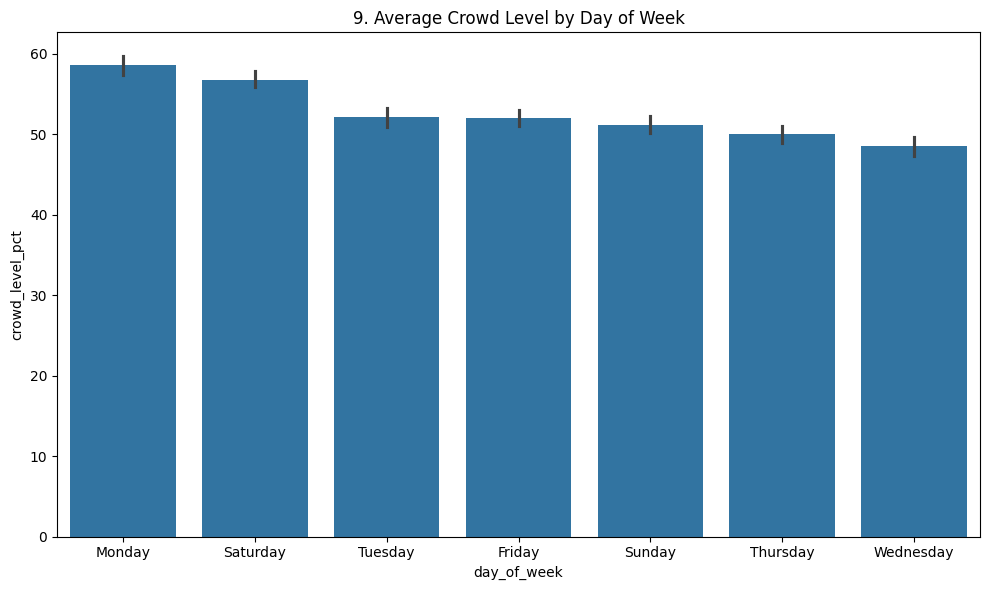

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='day_of_week', y='crowd_level_pct', order=df.groupby('day_of_week')['crowd_level_pct'].mean().sort_values(ascending=False).index)
plt.title(f'{plot_no}. Average Crowd Level by Day of Week')
show_fig()
plot_no += 1

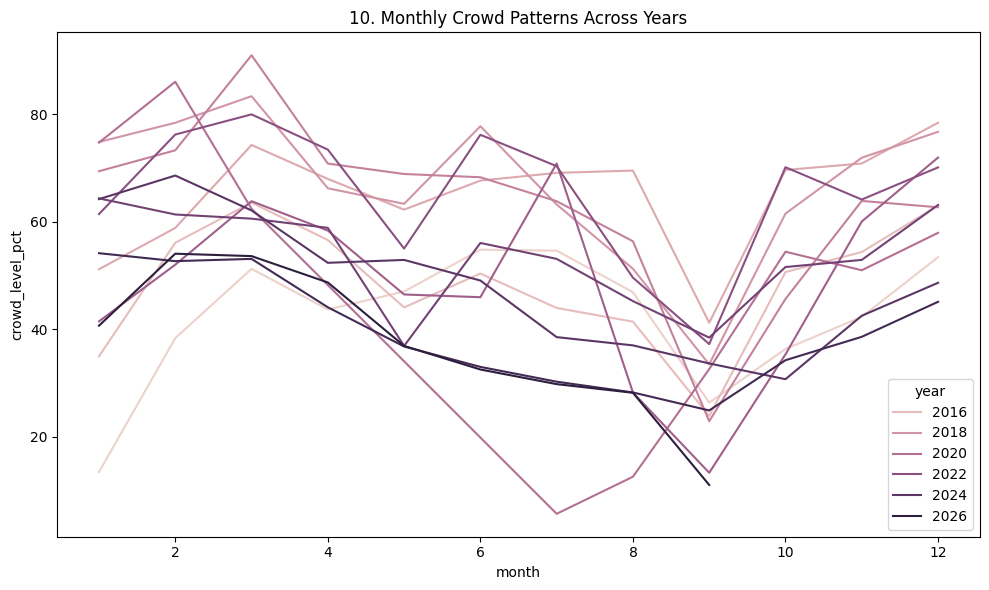

In [23]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='month', y='crowd_level_pct', hue='year', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Monthly Crowd Patterns Across Years')
show_fig()
plot_no += 1

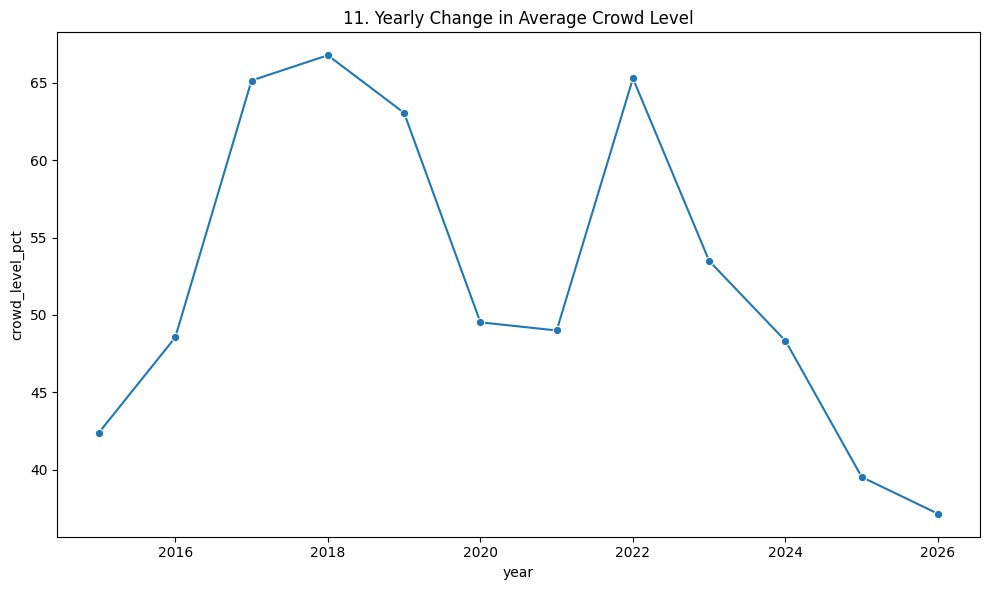

In [24]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='crowd_level_pct', marker='o', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Yearly Change in Average Crowd Level')
show_fig()
plot_no += 1

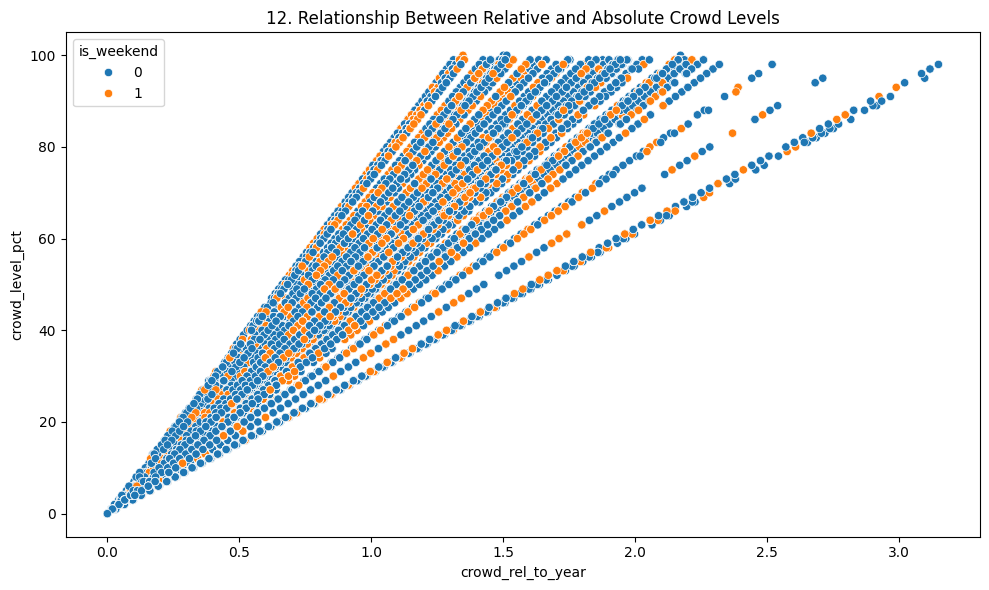

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='crowd_rel_to_year', y='crowd_level_pct', hue='is_weekend')
plt.title(f'{plot_no}. Relationship Between Relative and Absolute Crowd Levels')
show_fig()
plot_no += 1

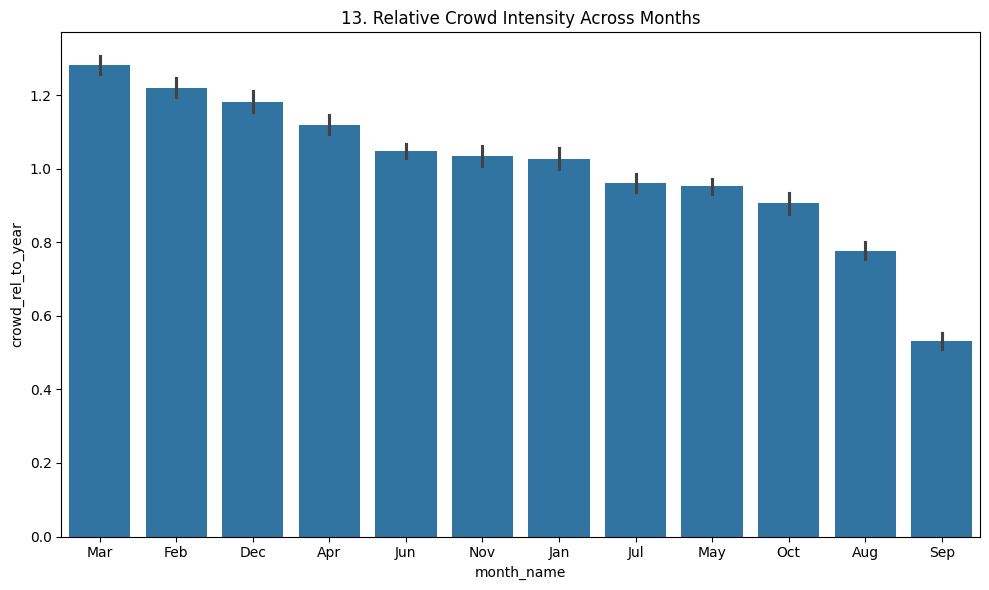

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='month_name', y='crowd_rel_to_year', order=df.groupby('month_name')['crowd_rel_to_year'].mean().sort_values(ascending=False).index)
plt.title(f'{plot_no}. Relative Crowd Intensity Across Months')
show_fig()
plot_no += 1

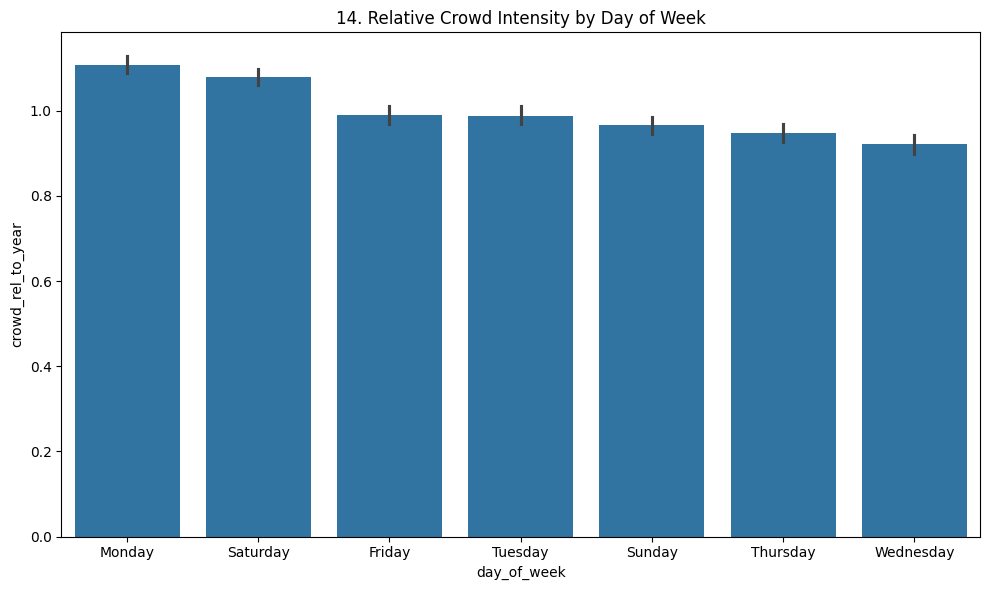

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='day_of_week', y='crowd_rel_to_year', order=df.groupby('day_of_week')['crowd_rel_to_year'].mean().sort_values(ascending=False).index)
plt.title(f'{plot_no}. Relative Crowd Intensity by Day of Week')
show_fig()
plot_no += 1

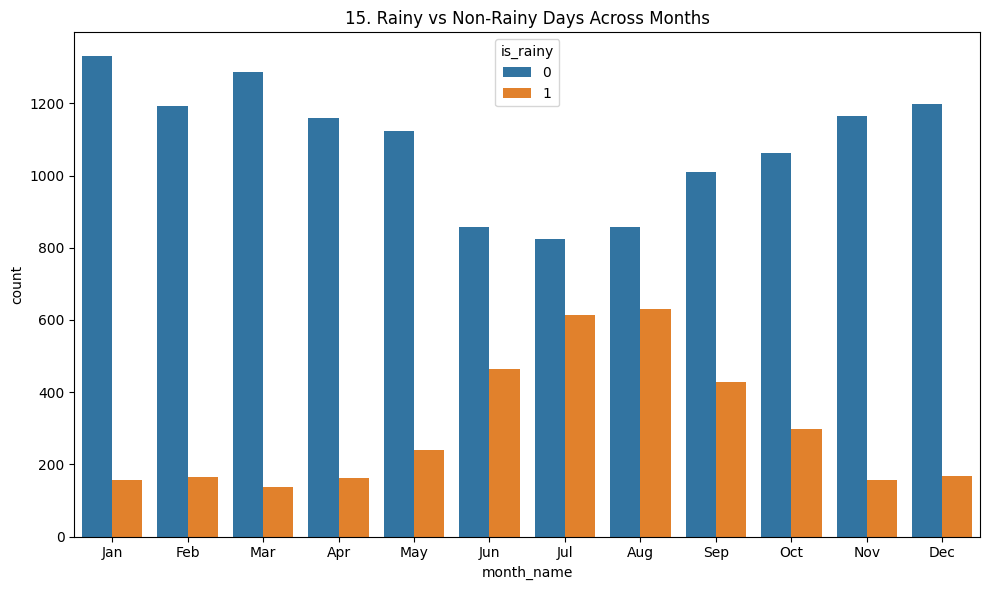

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='month_name', hue='is_rainy')
plt.title(f'{plot_no}. Rainy vs Non-Rainy Days Across Months')
show_fig()
plot_no += 1

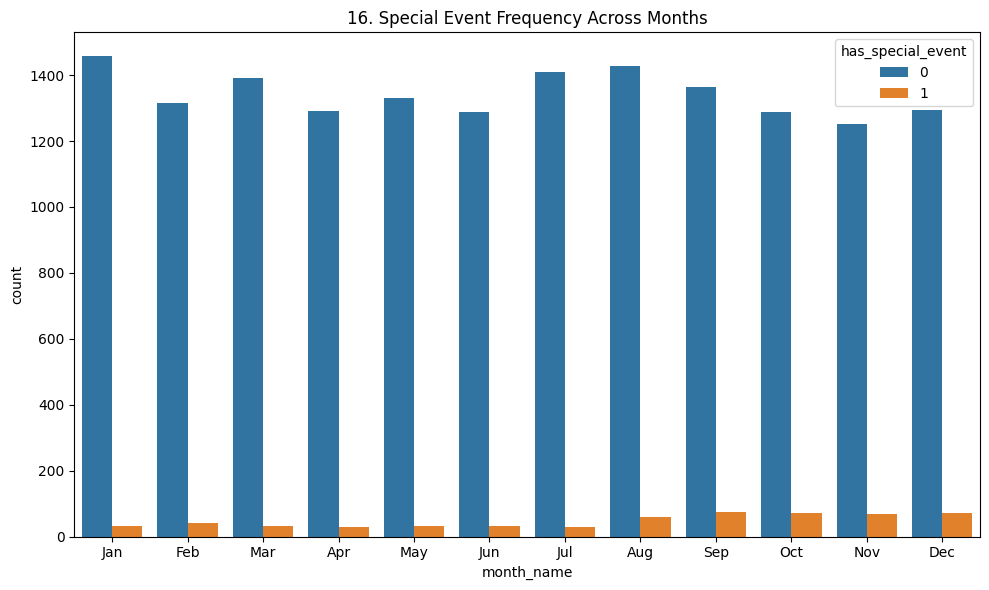

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='month_name', hue='has_special_event')
plt.title(f'{plot_no}. Special Event Frequency Across Months')
show_fig()
plot_no += 1

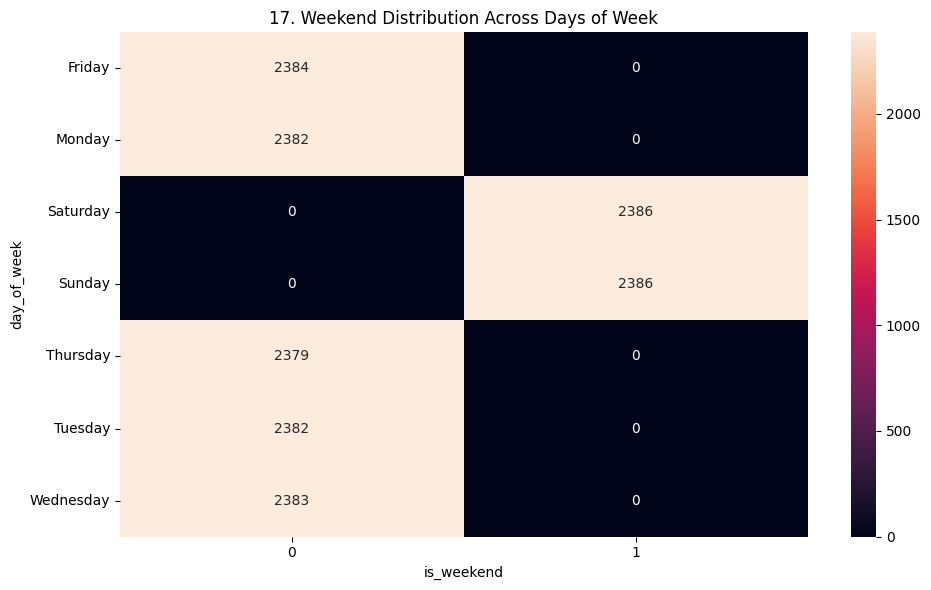

In [30]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df['day_of_week'], df['is_weekend']), annot=True, fmt='d')
plt.title(f'{plot_no}. Weekend Distribution Across Days of Week')
show_fig()
plot_no += 1

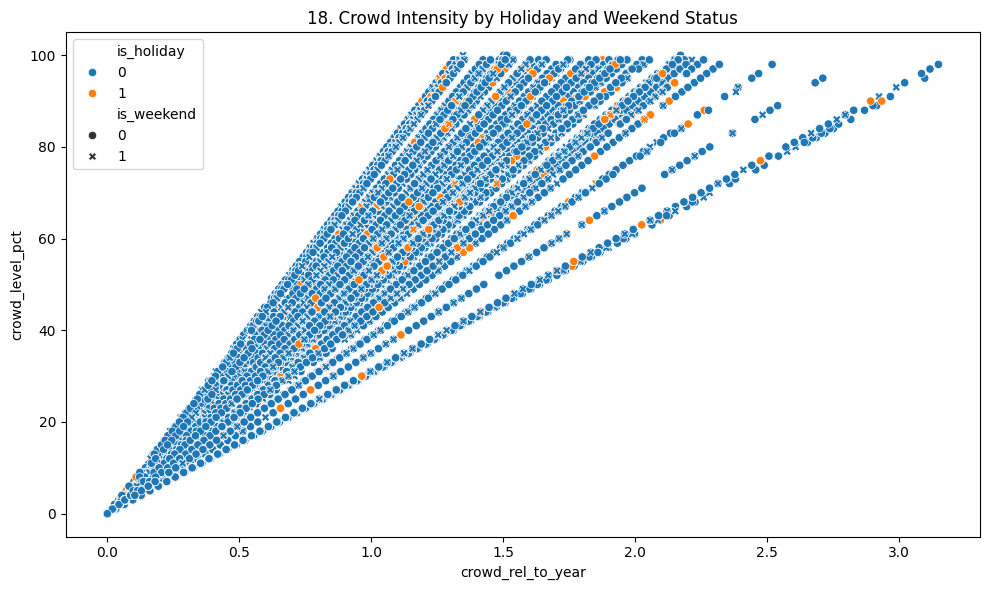

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='crowd_rel_to_year', y='crowd_level_pct', hue='is_holiday', style='is_weekend')
plt.title(f'{plot_no}. Crowd Intensity by Holiday and Weekend Status')
show_fig()
plot_no += 1

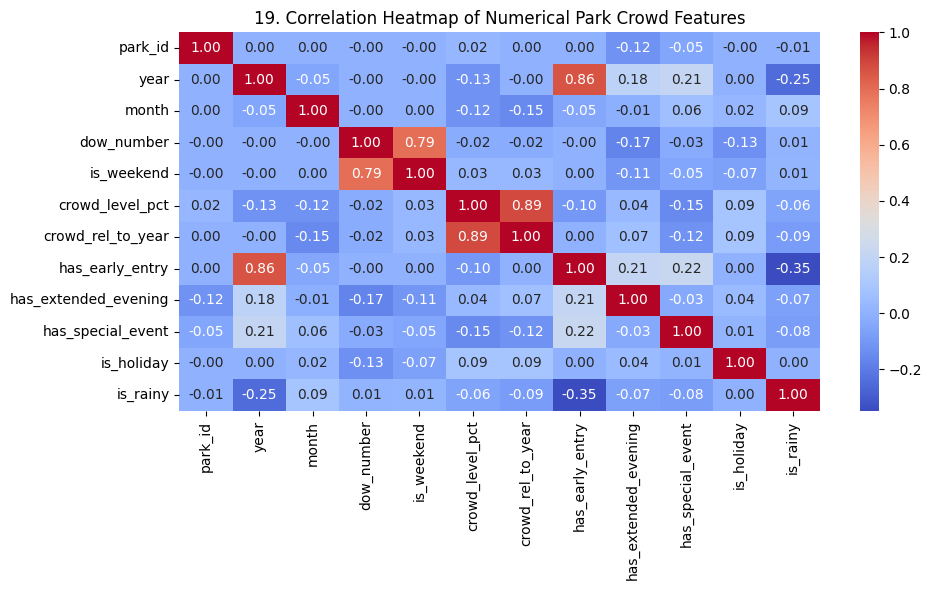

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Park Crowd Features')
show_fig()
plot_no += 1

# Model Training

## Select features and the crowd level target

In [33]:
X = df[['year', 'month', 'dow_number', 'is_weekend',
        'crowd_rel_to_year', 'has_early_entry',
        'has_extended_evening', 'has_special_event',
        'is_holiday', 'is_rainy']]

y = df['crowd_level_pct']

## Split the dataset into training and testing data

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scale the numerical features

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train the Gradient Boosting regression model

In [36]:
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

## Generate predictions on the test data

In [37]:
y_pred = model.predict(X_test)

## Calculate regression performance scores

In [38]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

R² Score: 0.9515
Mean Absolute Error: 4.5209
Root Mean Squared Error: 6.0631


## Plot actual versus predicted crowd levels

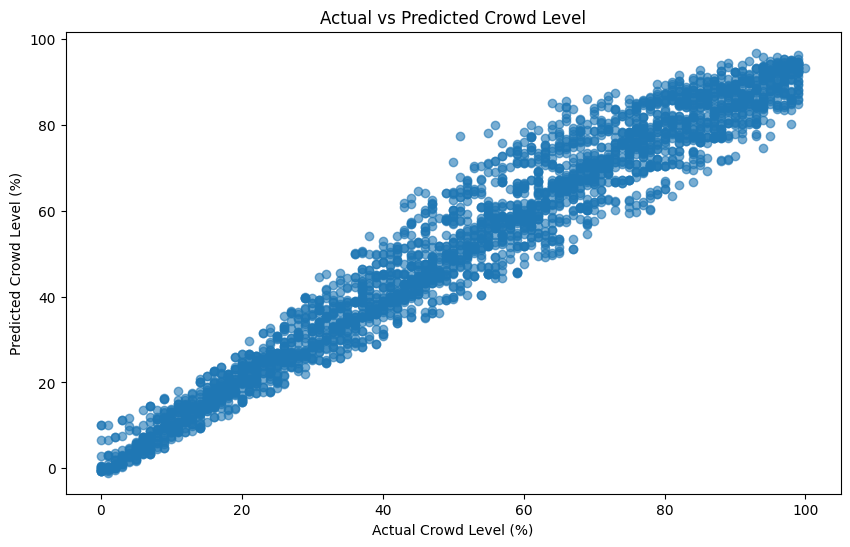

In [39]:
fig = plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Crowd Level (%)')
plt.ylabel('Predicted Crowd Level (%)')
plt.title('Actual vs Predicted Crowd Level')

plt.show()